<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/Atividade_Final_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Enrico de Andrade Bertozzi Miranda RGM: 11231100657

Curso: Engenharia de Software

Disciplina: Inteligência Artificial

Turma: 6A

Professor: Dr. Fabiano Bezerra Menegidio

### Descrição do Dataset
O presente dataset representa o perfil de microbiota intestinal de crianças com e sem Transtorno do Espectro Autista (ASD). Ele foi construído a partir de sequenciamento de 16S rRNA, gerando uma matriz de abundância categorizada de microrganismos.

Amostras: 61 crianças

* Grupo A → Crianças com ASD (Autistic Spectrum Disorder)

* Grupo B → Crianças com desenvolvimento típico (TD – Typically Developing)

Variáveis: 5619 microrganismos identificados em nível taxonômico (gênero e espécie), com nomes no formato padrão:

Exemplo: g__Faecalibacterium;s__Faecalibacterium prausnitzii

Natureza dos dados:

Cada célula da matriz indica a categoria de abundância relativa de um microrganismo em uma amostra.

Os valores são representados qualitativamente como low (baixa abundância), mid (abundância intermediária), high (alta abundância), além de casos específicos de absent (ausente) e present (presente).

Assim, o dataset reflete a composição microbiana intestinal de cada criança, permitindo investigar se há padrões que distinguem crianças com ASD das crianças com desenvolvimento típico.



In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, make_scorer, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline


RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Carregamento dos Dados

In [31]:
import pandas as pd

df = pd.read_csv("ASD_meta_abundance_discretized.csv")

df.head()

df.tail()

,Unnamed: 0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagiforme,...,g__Unclassified;s__Clostridium phage c-st,g__Unclassified;s__Enterococcus phage EFDG1,g__Unclassified;s__Podovirus Lau218,g__Sap6virus;s__Enterococcus phage VD13,g__Unclassified;s__Bacillus phage vB_BanS-Tsamsa,g__Unclassified;s__Gordonia phage GTE2,g__Alphabaculovirus;s__Hyphantria cunea nucleopolyhedrovirus,g__Potyvirus;s__Bean common mosaic virus,g__Potyvirus;s__Telosma mosaic virus,g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
55,B143,low,high,mid,low,low,low,low,low,mid,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
56,B152,mid,low,low,low,mid,low,high,low,mid,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
57,B156,low,low,mid,low,high,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
58,B158,low,low,mid,low,low,low,mid,low,high,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
59,B164,low,high,mid,low,mid,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Columns: 5620 entries, Unnamed: 0 to g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
dtypes: object(5620)
memory usage: 2.6+ MB


In [33]:
df.describe()

,Unnamed: 0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagiforme,...,g__Unclassified;s__Clostridium phage c-st,g__Unclassified;s__Enterococcus phage EFDG1,g__Unclassified;s__Podovirus Lau218,g__Sap6virus;s__Enterococcus phage VD13,g__Unclassified;s__Bacillus phage vB_BanS-Tsamsa,g__Unclassified;s__Gordonia phage GTE2,g__Alphabaculovirus;s__Hyphantria cunea nucleopolyhedrovirus,g__Potyvirus;s__Bean common mosaic virus,g__Potyvirus;s__Telosma mosaic virus,g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
count,60,60,60,60,60,60,60,60,60,60,...,60,60,60,60,60,60,60,60,60,60
unique,60,3,3,3,3,3,3,3,3,3,...,1,1,1,1,1,1,1,1,1,1
top,A3,low,low,mid,low,low,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
freq,1,30,25,37,47,38,53,36,54,34,...,60,60,60,60,60,60,60,60,60,60


# Tratamento dos Dados

In [34]:
# Remoção dos números presentes nos rotulos
df['Unnamed: 0'] = df['Unnamed: 0'].map(lambda x: x[0])

df.head()

,Unnamed: 0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,g__Hungatella;s__Hungatella hathewayi,g__Clostridium;s__uncultured Clostridium sp.,g__Butyricimonas;s__Butyricimonas virosa,g__Alistipes;s__Alistipes indistinctus,g__Unclassified;s__Firmicutes bacterium CAG:176,g__Clostridium;s__Clostridium sp. CAG:7,g__Unclassified;s__Firmicutes bacterium CAG:882,g__Lachnoclostridium;s__[Clostridium] asparagiforme,...,g__Unclassified;s__Clostridium phage c-st,g__Unclassified;s__Enterococcus phage EFDG1,g__Unclassified;s__Podovirus Lau218,g__Sap6virus;s__Enterococcus phage VD13,g__Unclassified;s__Bacillus phage vB_BanS-Tsamsa,g__Unclassified;s__Gordonia phage GTE2,g__Alphabaculovirus;s__Hyphantria cunea nucleopolyhedrovirus,g__Potyvirus;s__Bean common mosaic virus,g__Potyvirus;s__Telosma mosaic virus,g__Unclassified;s__Freshwater phage uvFW-CGR-AMD-COM-C203
0,A,mid,high,mid,low,low,low,high,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
1,A,mid,high,low,mid,low,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
2,A,low,mid,low,low,low,low,mid,low,high,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
3,A,mid,low,high,mid,low,mid,high,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent
4,A,mid,low,high,low,high,low,mid,low,low,...,absent,absent,absent,absent,absent,absent,absent,absent,absent,absent


In [35]:
# Removendo colunas unicas

df = df.drop(columns=df.columns[df.nunique() == 1])

In [36]:
# Aplicando técnica de Enconding
order = ['absent', 'present', 'low', 'mid', 'high']

# Serapação dos dados
target_df = df['Unnamed: 0']
data_df = df.drop(columns=['Unnamed: 0'])

# Criação do Encoder
# encoder = OneHotEncoder(
#     # Uso de List Compreension para definir ordem de todas as colunas
#     categories=[order for n in data_df],
#     handle_unknown='use_encoded_value',
#     unknown_value=-1)

encoder = OneHotEncoder(
     sparse_output=False,
     handle_unknown='ignore')


data = encoder.fit_transform(data_df)
ohd_columns = encoder.get_feature_names_out()

# # Novo DataFrame com dados transformados
data_df = pd.DataFrame(data, columns=ohd_columns)

# Visualização
data_df.head()

,g__Faecalibacterium;s__Faecalibacterium prausnitzii_high,g__Faecalibacterium;s__Faecalibacterium prausnitzii_low,g__Faecalibacterium;s__Faecalibacterium prausnitzii_mid,g__Hungatella;s__Hungatella hathewayi_high,g__Hungatella;s__Hungatella hathewayi_low,g__Hungatella;s__Hungatella hathewayi_mid,g__Clostridium;s__uncultured Clostridium sp._high,g__Clostridium;s__uncultured Clostridium sp._low,g__Clostridium;s__uncultured Clostridium sp._mid,g__Butyricimonas;s__Butyricimonas virosa_high,...,g__Unclassified;s__Skermania phage SPI1_high,g__Unclassified;s__Skermania phage SPI1_low,g__Unclassified;s__Vibrio phage vB_VhaS-tm_high,g__Unclassified;s__Vibrio phage vB_VhaS-tm_low,g__Unclassified;s__uncultured Mediterranean phage uvDeep-CGR0-AD1-C123_high,g__Unclassified;s__uncultured Mediterranean phage uvDeep-CGR0-AD1-C123_low,g__Unclassified;s__uncultured Mediterranean phage uvDeep1-CGR2-KM23-C896_high,g__Unclassified;s__uncultured Mediterranean phage uvDeep1-CGR2-KM23-C896_low,g__Unclassified;s__uncultured virus_high,g__Unclassified;s__uncultured virus_low
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [37]:
# Preparação dos dados para treino
X = data_df
Y = target_df

# Separação usando escala 80/20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)

# Modelo
classifier = SVC(random_state=RANDOM_STATE)

# Seletor K Best
selector = SelectKBest(f_classif)

# Criação do Pipeline
pipeline = Pipeline([
    ('selector', selector),
    ('classifier', classifier)
])

# Grid de parâmetros
params = {
    'selector__k': [100, 500],
    'classifier__C': [0.1, 1, 10, 100, 1000],
    'classifier__gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
    'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan

Acurácia: 0.5833333333333334
Melhores Paramêtros: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly', 'selector__k': 100}


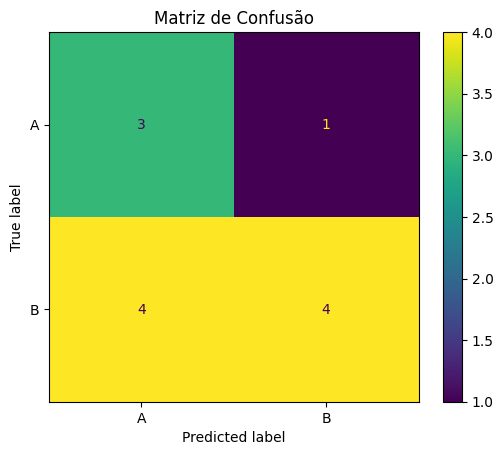

In [38]:
# Criação do Grid Search
gs = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'sensitivity': make_scorer(recall_score, pos_label='B'),
        'specificity': make_scorer(recall_score, pos_label='A'),
        'roc_auc': make_scorer(roc_auc_score, pos_label='B')
    },
    refit='accuracy',
    n_jobs=-1
)

# Treino
gs.fit(X_train, Y_train)

# Predição
Y_pred = gs.predict(X_test)

# Métricas
print(f'Acurácia: {accuracy_score(Y_test, Y_pred)}')
print(f'Melhores Paramêtros: {gs.best_params_}')
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, labels=['A', 'B'])
plt.title('Matriz de Confusão')
plt.show()

Vatagens do uso de GridSearch e suas limitações:
* GridSearch trabalha testando todas as permutações possíveis de hiper parâmetros, buscando assim a melhor combinação entre eles. No entanto, o custo computacional para esse método é altíssimo, sendo inviável em um conjunto massivo de dados.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  127   128   129   145   146   206   264   359   360   361   384   426
   427   462   471   482   568   604   605   606   607   692   759   760
   761   762   778   786   802   866   876   877   901   902   951   967
   975  1003  1004  1084  1109  1134  1137  1193  1251  1292  1293  1306
  1350  1374  1412  1478  1547  1593  1598  1634  1652  1768  1797  1798
  1799  1857  1861  1891  1892  1901  1953  1970  2067  2183  2368  2395
  2440  2464  2475  2557  2621  2630  2631  2728  2729  2744  2769  2841
  2887  2899  2970  2982  3109  3110  3117  3118  3128  3145  3161  3176
  3259  3276  3345  3460  3500  3670  3671  3678  3692  3737  3826  3900
  3943  3952  3965  3982 

Acurácia: 0.5833333333333334
Melhores Paramêtros: {'selector__k': 100, 'classifier__kernel': 'rbf', 'classifier__gamma': 'scale', 'classifier__C': 10}


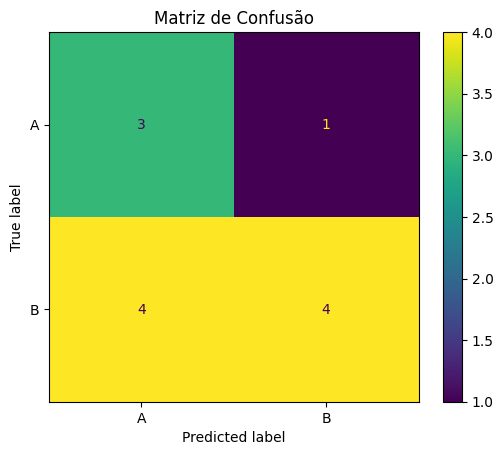

In [39]:
# Criação do Randomized Search
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'sensitivity': make_scorer(recall_score, pos_label='B'),
        'specificity': make_scorer(recall_score, pos_label='A'),
        'roc_auc': make_scorer(roc_auc_score, pos_label='B')
    },
    refit='accuracy',
    n_jobs=-1
)

# Treino
rs.fit(X_train, Y_train)

# Predição
Y_pred = rs.predict(X_test)

# Métricas
print(f'Acurácia: {accuracy_score(Y_test, Y_pred)}')
print(f'Melhores Paramêtros: {rs.best_params_}')
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, labels=['A', 'B'])
plt.title('Matriz de Confusão')
plt.show()


Vantagens do RandomizedSearchCV e suas limitações:
* Semelhante ao Grid Search, o Randomized Search testa diferentes valores para os hiper parâmtros do modelo, permitindo assim encontrar a "melhor" configuração. Seu funcionamento seleciona permutações de valores aleatórios para teste, cobrindo uma parte das combinações possíveisn não todas. Essa características reduz o poder computacional necessário na busca da melhor otimização.

* Sua limitação está em não percorrer todos os possiveis parâmetros, podendo deixar passar uma configuração mais precisa.

### Análise entre Grid Search e Randomized Search
* Grid Search e Randomized Search buscam o mesmo objetivo, encontrar a melhor combinação de hiper parâmetros para o modelo.
* Grid Search procura por todas as combinações possíveis, tendo um custo computacional excessivo. Seu tempo de execução para esse teste, levou cerca de 4 minutos para encontrar uma combinação, essa resultou em 58% de acurácia.
* Randomized Search usa combinações aleatórias de hiper parâmetros para encontrar a melhor combinação, esse meio usa muito menos poder computacional que o anterior. Seus resultados foram um acurácia de 58%, e um tempo de execução muito menor, apenas 11 segundos.